In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, auc
from sklearn.datasets import load_wine             # 와인 데이터셋

import joblib                                      # 파이썬 객체 저장을 위한 joblib
import tensorflow as tf                            # 텐서플로우 lib

# 케라스의 모델 저장 및 로드 기능을 사용하기 위한 필요 모듈
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

np.random.seed(42)
tf.random.set_seed(42)

In [13]:
# ================================
# 1. 데이터 읽어오기 (와인 데이터셋)
# ================================

data = load_wine()
X = data.data           # 입력 x 데이터
y = data.target         # 타겟 레이블 y 데이터

feature_names = data.feature_names   # 특성 이름
df = pd.DataFrame(X, columns=feature_names)  # 데이터 확인을 데이터프레임으로 변환

df['target'] = y   # 타겟 컬럼을 추가

print('전체 데이터 shape:', df.shape)

전체 데이터 shape: (178, 14)


In [14]:
df.head(10)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
5,14.20,1.76,2.45,15.2,112.0,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450.0,0
6,14.39,1.87,2.45,14.6,96.0,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290.0,0
7,14.06,2.15,2.61,17.6,121.0,2.60,2.51,0.31,1.25,5.05,1.06,3.58,1295.0,0
8,14.83,1.64,2.17,14.0,97.0,2.80,2.98,0.29,1.98,5.20,1.08,2.85,1045.0,0
9,13.86,1.35,2.27,16.0,98.0,2.98,3.15,0.22,1.85,7.22,1.01,3.55,1045.0,0


In [15]:
# ================================
# 2. 학습용/테스트용 데이터 분리
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [16]:
# ================================
# 3. 스케일링
# ================================
scaler = StandardScaler()                       # 
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
# ================================
# 4. one-hot 인코드 수행
# ================================
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

In [18]:
# ================================
# 5. 모델 정의
# ================================
model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)))  # 첫 번째 은닉층 추가
model.add(Dropout(0.2))                # 드롭아웃 추가

model.add(Dense(32, activation='relu')) # 두 번째 은닉층 추가

model.add(Dense(3, activation='softmax')) # 출력층은 클래스 3개, 활성화함수는 softmax 사용

C:\Users\ui203\anaconda3\envs\aigugbi\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [25]:
# ================================
# 6. 모델 컴파일
# ================================

# 손실함수는 binary crossentropy, 평가지표는 accuracy를 사용

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 7. 조기 종료
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [26]:
# ================================
# 7. 모델 학습
# ================================

# 모델을 학습하고, history 객체에 학습 과정을 저장
history = model.fit(
    X_train_scaled,
    y_train_cat,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.3009 - loss: 1.2265 - val_accuracy: 0.3103 - val_loss: 1.2145
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5841 - loss: 1.0331 - val_accuracy: 0.4828 - val_loss: 0.9884
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6195 - loss: 0.9286 - val_accuracy: 0.8276 - val_loss: 0.8207
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7257 - loss: 0.8428 - val_accuracy: 0.8966 - val_loss: 0.6946
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8673 - loss: 0.7002 - val_accuracy: 0.9310 - val_loss: 0.5862
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8496 - loss: 0.6247 - val_accuracy: 0.9655 - val_loss: 0.4886
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9204 - loss: 0.5340 - val_accuracy: 0.9655 - val_loss: 0.4063
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9115 - loss: 0.4620 - val_accuracy: 1.0000 - val_loss:

In [30]:
# ================================
# 8. 모델 평가
# ================================

# 테스트 데이터에 대해 손실과 정확도 평가
test_loss, test_acc = model.evaluate(X_test_scaled, y_test_cat, verbose=0)

# 평가 결과 출력
print('테스트 손실: ', test_loss)
print('테스트 정확도: ', test_acc)

# 예측 확률
y_prob = model.predict(X_test_scaled)

# 확률 0 또는 1 클래스로 변환
y_pred = np.argmax(y_prob, axis=1)

# 정확도 계산
acc = accuracy_score(y_test, y_pred)

# confusion_matrix 계산
cm = confusion_matrix(y_test, y_pred)

# 분류 리포트 출력
print('정확도:', acc)
print('confusion matrix: ', cm)
print('분류 리포트: \n', classification_report(y_test, y_pred))

테스트 손실:  0.05440734699368477
테스트 정확도:  0.9722222089767456
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
정확도: 0.9722222222222222
confusion matrix:  [[12  0  0]
 [ 0 14  0]
 [ 0  1  9]]
분류 리포트: 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.93      1.00      0.97        14
           2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



In [31]:
# ================================
# 9. 학습결과 저장
# ================================

# 모델을 파일로 저장
model.save('./results/multiclass_model.h5')  # 'multiclass_model.keras'

# 스케일러를 파일로 저장
joblib.dump(scaler, './results/multiclass_model.pkl')

#학습이력을 데이터프레임으로 변환
history_df = pd.DataFrame(history.history)

# 학습이력을 csv파일로 저장
history_df.to_csv('./results/multiclass_model.csv', index=False)

# 저장 완료 메세지 출력
print("이진분류 모델, 스케일러, 학습이력 저장 완료")

이진분류 모델, 스케일러, 학습이력 저장 완료


In [32]:
# ================================
# 10. 저장된 결과 읽어오기
# ================================
# 저장된 모델을 다시 불러오기
loaded_model = tf.keras.models.load_model('./results/multiclass_model.h5')

# 저장된 스케일러를 다시 불러오기
loaded_scaler = joblib.load('./results/multiclass_model.pkl')

In [34]:
# ================================
# 11. 저장된 결과 읽어오기
# ================================
new_data = X_test[:5]
new_data_scaled = loaded_scaler.transform(new_data)
new_prob = loaded_model.predict(new_data_scaled)

# 예측 확률값을 0/1로 변환 new_pred = (new_prob >= 0.5).astype(int).flatten()
new_pred = np.argmax(new_prob, axis=1)

#예측 결과 출력
for i in range(len(new_data)):
    print(f"{i+1}번 샘플 - 예측클래스: {new_pred[i]}, 클래스 별 확률: {new_prob[i]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1번 샘플 - 예측클래스: 0, 클래스 별 확률: [9.9999893e-01 1.0226796e-06 4.5984152e-08]
2번 샘플 - 예측클래스: 1, 클래스 별 확률: [0.00092332 0.70506436 0.29401237]
3번 샘플 - 예측클래스: 0, 클래스 별 확률: [9.9994516e-01 5.1076284e-05 3.8679309e-06]
4번 샘플 - 예측클래스: 1, 클래스 별 확률: [1.3200225e-01 8.6787456e-01 1.2325175e-04]
5번 샘플 - 예측클래스: 1, 클래스 별 확률: [4.8899418e-04 9.9944645e-01 6.4563450e-05]


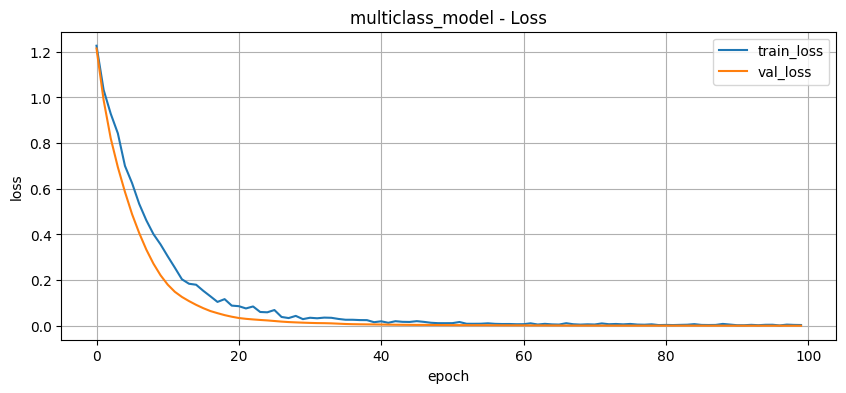

In [35]:
# ================================
# 11. 시각화 결과 확인  (Loss 그래프)
# ================================

# 학습결과 시각화
plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('multiclass_model - Loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.grid(True)    # 그래프를 격자로 표시
plt.show()

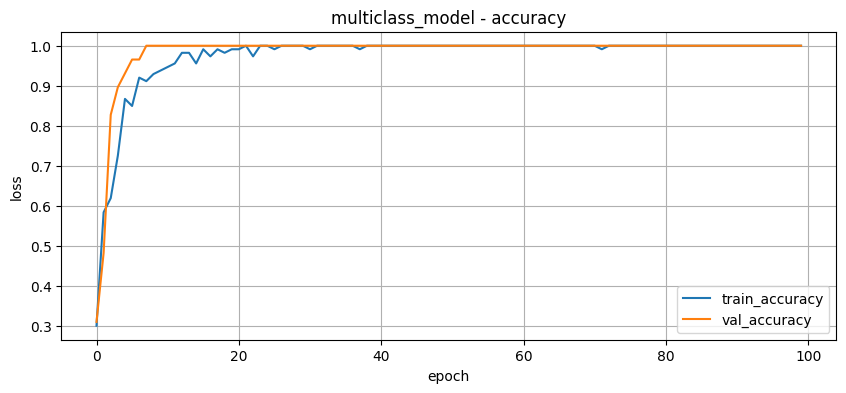

In [36]:
# ================================
# 11-2. 학습 결과표)
# ================================

# 학습 정확도 결과 시각화
plt.figure(figsize=(10,4))
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('multiclass_model - accuracy')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.grid(True)    # 그래프를 격자로 표시
plt.show()

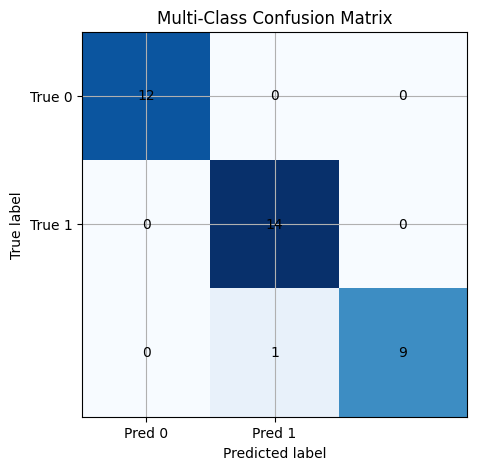

In [39]:
# ================================
# 11-3. 시각화 결과 확인
# ================================

# confusion matrix 시각화
plt.figure(figsize=(6,5))
plt.imshow(cm, cmap='Blues')
plt.title('Multi-Class Confusion Matrix')

# x축과 y축 눈금 설정
plt.xticks([0,1], ['Pred 0', 'Pred 1'])
plt.yticks([0,1], ['True 0', 'True 1'])

# CM 내부에 숫자 표시
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.grid(True)
plt.show()